# 0. Imports

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118
     ---------------------------------------- 0.0/6.2 MB ? eta -:--:--
     ---------------------------------------- 6.2/6.2 MB 76.0 MB/s eta 0:00:00
     ---------------------------------------- 0.0/536.2 kB ? eta -:--:--
     ---------------------------------------- 536.2/536.2 kB ? eta 0:00:00
   ---------------------------------------- 0.0/2.7 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 GB 99.4 MB/s eta 0:00:28
    --------------------------------------- 0.0/2.7 GB 99.4 MB/s eta 0:00:28
    --------------------------------------- 0.1/2.7 GB 95.6 MB/s eta 0:00:28
   - -------------------------------------- 0.1/2.7 GB 95.6 MB/s eta 0:00:28
   - -------------------------------------- 0.1/2.7 GB 92.3 MB/s eta 0:00:29
   - -------------------------------------- 0.1/2.7 GB 93.3 MB/s eta 0:00:29
   -- ------------------------------------- 0.1/2.7 GB 93.8 MB/s eta 0:00:28
   -- -----------------------------


[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from itertools import combinations
from collections import Counter
import torch
from torch import nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

In [2]:
import os
data_path = os.path.join(os.getcwd(), 'data')

# 1. Helper Functions

## 1.2 Find the most frequent combinations of categories in a df column

In [3]:
def get_top_k_p_combinations(df, comb_p, topk, output_freq=False):
    '''
    params:
        df: input dataframe
        comb_p: number of elements in each combination (e.g., there are two elements in the combination {fried chicken, chicken and waffle}, and three elements in the combination {fried chicken, chicken and waffle, chicken fried rice})
        topk: number of most frequent combinations to retrieve
        output_freq: whether to return the frequencies of retrieved combinations

    return:
        1. output_freq = True: a list X where each element is a tuple containing a combination tuple and corresponding frequency, and the elements are stored in the descending order of their frequencies
        2. output_freq = False: a list X where each element is a tuple containing a combination tuple, and the elements are stored in the descending order of their frequencies
    '''
    def get_category_combinations(categories, comb_p=2):
        return list(combinations(categories, comb_p))
    all_categories_p_combos = df["category"].apply(lambda x: get_category_combinations(x, comb_p)).values.tolist()
    all_categories_p_combos = [tuple(t) for item in all_categories_p_combos for t in item]
    tmp = dict(Counter(all_categories_p_combos))
    sorted_categories_combinations = list(sorted(tmp.items(), key=lambda x: x[1], reverse=True))
    if output_freq:
        return sorted_categories_combinations[:topk]
    else:
        return [t[0] for t in sorted_categories_combinations[:topk]]

## 1.3 Create a OHE (or "wide feature representation") of each row in the column of a df

# 2. Data Handling

## 2.1 Data Exploration

In [4]:
prediction_data = pd.read_csv(os.path.join(data_path, 'prediction.csv'))
product_data = pd.read_json(os.path.join(data_path, 'product.json'))
review_data = pd.read_csv(os.path.join(data_path, 'review.csv'))
validation_data = pd.read_csv(os.path.join(data_path, 'validation.csv'))

print(f"Prediction data shape: {prediction_data.shape}")
print(f"Product data shape: {product_data.shape}")
print(f"Review data shape: {review_data.shape}")
print(f"Validation data shape: {validation_data.shape}")

Prediction data shape: (6633, 3)
Product data shape: (6309, 17)
Review data shape: (52512, 5)
Validation data shape: (6596, 3)


In [158]:
review_data

,ReviewerID,ProductID,Text,Summary,Star
0,A1XJXYKOWCH9XT,B000FBFMHU,Liked the movie. Loved the book. It really giv...,Liked the movie. Loved the book!,5.0
1,A1K4S4MWXI9E9M,B000FC27TA,Purchased more out of curiosity than any real ...,"Not my favorite, but...",3.0
2,A3LF914GG87TWP,B000FC27TA,"I actually received this text as an ebook, sin...",An interesting read,4.0
3,A1CNQTCRQ35IMM,B000FCKPG2,REVIEWER'S OPINION:\r\nThis was labeled as rom...,This was labeled romance but there was less ro...,2.0
4,AU510CVD9XDG,B000GCFWXW,I have been saving the Argeneau novels for awh...,Science Fiction not Paranormal Romance,2.0
...,...,...,...,...,...
52507,A3JVZY05VLMYEM,B01FLJUZ0E,She can't do anything right according to her f...,What Can She Do,5.0
52508,A2U06P692IZOSF,B01FLJUZ0E,Better late than never!!\r\nKitty Konstantine ...,BART & KITTY CAT MAKE SPARKS FLY!!,5.0
52509,A3RPL8JIS2XMJ3,B01FLJUZ0E,This book was great. Bartholomew finally gets ...,LOVE THE SAINTS,5.0
52510,A1XMFCMIANCQRW,B01FPYJS1M,I read for a honest review for the author.\r\n...,"Loved Lee and Raina together, Ricky is evil an...",4.0


In [159]:
prediction_data

,ReviewerID,ProductID,Star
0,A2MK1L1Y74WTWH,B01GT5XDFS,0
1,A19I68RW4PBT29,B00OME9OQQ,0
2,A1UPHTDW5GM12T,B01GSRNLOK,0
3,A1LFIFPYMOJ8RV,B01CUJYMR0,0
4,A10Y597K071WTQ,B004SI455Q,0
...,...,...,...
6628,A23Y4UGTFDMZOP,B00J5327X6,0
6629,A2PFNDDKHOOMZU,B01G0GIXJ2,0
6630,A1K4S4MWXI9E9M,B01FKDKB96,0
6631,AOLHNMI8G8R6K,B00NUDPR66,0


In [160]:
validation_data

,ReviewerID,ProductID,Star
0,A25X28UZCW2J6G,B00K9V6B94,4.0
1,A1FUH1O6FCTUYG,B00GZANS6M,5.0
2,AAUVEEG5YLZAX,B01864DDVO,5.0
3,A3VQLGTYTL5196,B001BXNQ2O,5.0
4,A10JAUCIGVRW9F,B0116MZUS2,5.0
...,...,...,...
6591,A3TC60MGLW1I76,B00EHSUFD8,4.0
6592,AGE0YGLF7L2ZL,B014LQ18CW,4.0
6593,AT2ZB20OCU7X2,B00ZRDPPU0,4.0
6594,A1ACUN6A2LYVMW,B01EKIELGG,1.0


## 2.2 Preprocessing

### 2.2.1 Merging the train_df and val_df

In [161]:
import json
with open('data/product.json', 'r') as f:
    product_data_json = json.load(f)


Create a dictionary version of product data with key=product_id for clarity

In [162]:
product_data_json_structured = {product_data_json[i]['ProductID']: product_data_json[i] for i in range(len(product_data_json))}

## Extracting Relevant Information from Product Data

In [163]:
validation_data

,ReviewerID,ProductID,Star
0,A25X28UZCW2J6G,B00K9V6B94,4.0
1,A1FUH1O6FCTUYG,B00GZANS6M,5.0
2,AAUVEEG5YLZAX,B01864DDVO,5.0
3,A3VQLGTYTL5196,B001BXNQ2O,5.0
4,A10JAUCIGVRW9F,B0116MZUS2,5.0
...,...,...,...
6591,A3TC60MGLW1I76,B00EHSUFD8,4.0
6592,AGE0YGLF7L2ZL,B014LQ18CW,4.0
6593,AT2ZB20OCU7X2,B00ZRDPPU0,4.0
6594,A1ACUN6A2LYVMW,B01EKIELGG,1.0


#### Find Product IDs intersection with review and validation data

In [164]:
with open('data/product.json', 'r') as f:
    product_data_json = json.load(f)

product_data_ids = set([product_data_json[i]['ProductID'] for i in range(len(product_data_json))])
review_data_ids = set(review_data['ProductID'].unique())
validation_data_ids = set(validation_data['ProductID'].unique())
prediction_data_ids = set(prediction_data['ProductID'].unique())

review_and_product = review_data_ids.intersection(product_data_ids)
validation_and_product = validation_data_ids.intersection(product_data_ids)

prediction_and_product = set(prediction_data['ProductID'].unique())
prediction_and_product = prediction_data_ids.intersection(product_data_ids)


In [165]:
len(validation_and_product)

2491

### Organize the dataframes for the intersected data

In [166]:
product_data_df = pd.DataFrame(
    {
        "ProductID": list(product_data_ids),
        "category": [product_data_json_structured[key]['category'] for key in product_data_ids],
        "author": [product_data_json_structured[key]['brand'] for key in product_data_ids],
        "rank": [product_data_json_structured[key]['rank'] for key in product_data_ids]
    }
)

product_data_df['author'] = product_data_df['author'].str.replace('Visit Amazon\'s ', '').str.replace(' Page', '').str.strip()
product_data_df['rank'] = product_data_df['rank'].str.replace(r'[^\d]', '', regex=True).fillna(0).astype(int)

In [167]:
product_data_df

,ProductID,category,author,rank
0,B01A01REKM,"[Kindle Store, Kindle eBooks, Science Fiction ...",PJ Strebor,2875
1,B00BNB54RE,"[Kindle Store, Kindle eBooks, Literature & Fic...",Shareef Jaudon,761405
2,B00CP7M572,"[Kindle Store, Kindle eBooks, Romance]",Elizabeth A Reeves,103094
3,B00H7K5UB0,"[Kindle Store, Kindle eBooks, Literature & Fic...",Melody Grace,652
4,B006LAOIWY,"[Kindle Store, Kindle eBooks, Literature & Fic...",William F. Brown,400053
...,...,...,...,...
6304,B00MUXSBBA,"[Kindle Store, Kindle eBooks, Literature & Fic...",Callie Hart,222245
6305,B00AG6T35Q,"[Kindle Store, Kindle eBooks, Mystery, Thrille...",Carolyn McCray,540222
6306,B016OR83AG,"[Kindle Store, Kindle eBooks, Literature & Fic...",Helena Hunting,20943
6307,B018DK6LM4,"[Kindle Store, Kindle eBooks, Mystery, Thrille...",Amelia Morgan,3334


##### For Review data

In [168]:
columns_of_interest = ["category", "brand", "rank"]
product_review_df = pd.DataFrame({
    "ProductID": list(review_and_product),
    "category": [product_data_json_structured[key]['category'] for key in review_and_product],
    "author": [product_data_json_structured[key]['brand'] for key in review_and_product],
    "rank": [product_data_json_structured[key]['rank'] for key in review_and_product]
})

product_review_df['author'] = product_review_df['author'].str.replace('Visit Amazon\'s ', '').str.replace(' Page', '').str.strip()
product_review_df['rank'] = product_review_df['rank'].str.replace(r'[^\d]', '', regex=True).fillna(0).astype(int)
# product_review_df['category'] = product_review_df['category'].str.replace('&', 'and').str.replace('andamp', '').str.strip()
# product_review_df['category'] = product_review_df['category'].str.replace(r'[^a-zA-Z\s]', '', regex=True).str.strip()
product_review_df

,ProductID,category,author,rank
0,B01A01REKM,"[Kindle Store, Kindle eBooks, Science Fiction ...",PJ Strebor,2875
1,B00CP7M572,"[Kindle Store, Kindle eBooks, Romance]",Elizabeth A Reeves,103094
2,B00BNB54RE,"[Kindle Store, Kindle eBooks, Literature & Fic...",Shareef Jaudon,761405
3,B00H7K5UB0,"[Kindle Store, Kindle eBooks, Literature & Fic...",Melody Grace,652
4,B006LAOIWY,"[Kindle Store, Kindle eBooks, Literature & Fic...",William F. Brown,400053
...,...,...,...,...
6304,B00MUXSBBA,"[Kindle Store, Kindle eBooks, Literature & Fic...",Callie Hart,222245
6305,B00AG6T35Q,"[Kindle Store, Kindle eBooks, Mystery, Thrille...",Carolyn McCray,540222
6306,B016OR83AG,"[Kindle Store, Kindle eBooks, Literature & Fic...",Helena Hunting,20943
6307,B018DK6LM4,"[Kindle Store, Kindle eBooks, Mystery, Thrille...",Amelia Morgan,3334


##### For validation data

In [173]:
product_validation_df = pd.DataFrame({
    "ProductID": list(validation_and_product),
    "category": [product_data_json_structured[key]['category'] for key in validation_and_product],
    "author": [product_data_json_structured[key]['brand'] for key in validation_and_product],
    "rank": [product_data_json_structured[key]['rank'] for key in validation_and_product]
})

product_validation_df['author'] = product_validation_df['author'].str.replace('Visit Amazon\'s ', '').str.replace(' Page', '').str.strip()
product_validation_df['rank'] = product_validation_df['rank'].str.replace(r'[^\d]', '', regex=True).fillna(0).astype(int)
# product_validation_df['category'] = product_validation_df['category'].str.replace('&', 'and').str.replace('andamp', '').str.strip()
# product_validation_df['category'] = product_validation_df['category'].str.replace(r'[^a-zA-Z\s]', '', regex=True).str.strip()
product_validation_df

,ProductID,category,author,rank
0,B00WZWMRC0,"[Kindle Store, Kindle eBooks, Mystery, Thrille...",Darla Dunbar,9003
1,B00H8TBQCC,"[Kindle Store, Kindle eBooks, Romance]",Susan Kaye Quinn,3263
2,B00IZL6KTG,"[Kindle Store, Kindle eBooks, Literature & Fic...",Evangeline Anderson,117101
3,B00CP7M572,"[Kindle Store, Kindle eBooks, Romance]",Elizabeth A Reeves,103094
4,B00MVK5RIW,"[Kindle Store, Kindle eBooks, Romance]",Erin Nicholas,45587
...,...,...,...,...
2486,B016OR83AG,"[Kindle Store, Kindle eBooks, Literature & Fic...",Helena Hunting,20943
2487,B018DK6LM4,"[Kindle Store, Kindle eBooks, Mystery, Thrille...",Amelia Morgan,3334
2488,B00G7RANLG,"[Kindle Store, Kindle eBooks, Literature & Fic...",Helena Hunting,145917
2489,B01C8CLGR8,"[Kindle Store, Kindle eBooks, Romance]",Monica La Porta,303358


##### For Prediction Data

In [174]:
product_prediction_df = pd.DataFrame({
    "ProductID": list(prediction_and_product),
    "category": [product_data_json_structured[key]['category'] for key in prediction_and_product],
    "author": [product_data_json_structured[key]['brand'] for key in prediction_and_product],
    "rank": [product_data_json_structured[key]['rank'] for key in prediction_and_product]
})

product_prediction_df['author'] = product_prediction_df['author'].str.replace('Visit Amazon\'s ', '').str.replace(' Page', '').str.strip()
product_prediction_df['rank'] = product_prediction_df['rank'].str.replace(r'[^\d]', '', regex=True).fillna(0).astype(int)
# product_prediction_df['category'] = product_prediction_df['category'].str.replace('&', 'and').str.replace('andamp', '').str.strip()
# product_prediction_df['category'] = product_prediction_df['category'].str.replace(r'[^a-zA-Z\s]', '', regex=True).str.strip()
product_prediction_df

,ProductID,category,author,rank
0,B00WZWMRC0,"[Kindle Store, Kindle eBooks, Mystery, Thrille...",Darla Dunbar,9003
1,B00H8TBQCC,"[Kindle Store, Kindle eBooks, Romance]",Susan Kaye Quinn,3263
2,B01A01REKM,"[Kindle Store, Kindle eBooks, Science Fiction ...",PJ Strebor,2875
3,B00H7K5UB0,"[Kindle Store, Kindle eBooks, Literature & Fic...",Melody Grace,652
4,B0142IHZPI,"[Kindle Store, Kindle eBooks, Literature & Fic...",Emily Bleeker,2087
...,...,...,...,...
2466,B00H9KEAKA,"[Kindle Store, Kindle eBooks, Romance]",Kat Simons,9683
2467,B01C8CLGR8,"[Kindle Store, Kindle eBooks, Romance]",Monica La Porta,303358
2468,B00GMWKE2Y,"[Kindle Store, Kindle eBooks, Romance]",Maggie Shayne,37247
2469,B00GG4TJAQ,"[Kindle Store, Kindle eBooks, Science Fiction ...",Deanna Chase,305863


#### Merge and Create the Train, validation and Test DF

In [231]:
train_df = pd.merge(review_data[['ReviewerID', 'ProductID', 'Star']], product_review_df, on='ProductID').reset_index(drop=True)
val_df = pd.merge(validation_data, product_data_df, on='ProductID', how="left").reset_index(drop=True)
pred_df = pd.merge(prediction_data, product_data_df, on='ProductID', how="left").reset_index(drop=True)

In [232]:
train_df

,ReviewerID,ProductID,Star,category,author,rank
0,A1XJXYKOWCH9XT,B000FBFMHU,5.0,"[Kindle Store, Kindle eBooks, Biographies & Me...",Frank W. Abagnale,59404
1,A1K4S4MWXI9E9M,B000FC27TA,3.0,"[Kindle Store, Kindle eBooks, Politics & Socia...",Karl Marx,1358073
2,A3LF914GG87TWP,B000FC27TA,4.0,"[Kindle Store, Kindle eBooks, Politics & Socia...",Karl Marx,1358073
3,A1CNQTCRQ35IMM,B000FCKPG2,2.0,"[Kindle Store, Kindle eBooks, Romance]",Allison Brennan,94006
4,AU510CVD9XDG,B000GCFWXW,2.0,"[Kindle Store, Kindle eBooks, Mystery, Thrille...",Lynsay Sands,31652
...,...,...,...,...,...,...
52323,A3JVZY05VLMYEM,B01FLJUZ0E,5.0,"[Kindle Store, Kindle eBooks, Literature & Fic...",Becca Fanning,759249
52324,A2U06P692IZOSF,B01FLJUZ0E,5.0,"[Kindle Store, Kindle eBooks, Literature & Fic...",Becca Fanning,759249
52325,A3RPL8JIS2XMJ3,B01FLJUZ0E,5.0,"[Kindle Store, Kindle eBooks, Literature & Fic...",Becca Fanning,759249
52326,A1XMFCMIANCQRW,B01FPYJS1M,4.0,"[Kindle Store, Kindle eBooks, Literature & Fic...",Marci Fawn,357833


In [233]:
val_df

,ReviewerID,ProductID,Star,category,author,rank
0,A25X28UZCW2J6G,B00K9V6B94,4.0,"[Kindle Store, Kindle eBooks, Science Fiction ...",Erin Kellison,607901.0
1,A1FUH1O6FCTUYG,B00GZANS6M,5.0,"[Kindle Store, Kindle eBooks, Literature & Fic...",Evangeline Anderson,74267.0
2,AAUVEEG5YLZAX,B01864DDVO,5.0,"[Kindle Store, Kindle eBooks, Literature & Fic...",Lucia Jordan,13716.0
3,A3VQLGTYTL5196,B001BXNQ2O,5.0,"[Kindle Store, Kindle eBooks, Literature & Fic...",Eve Vaughn,730348.0
4,A10JAUCIGVRW9F,B0116MZUS2,5.0,NaN,NaN,NaN
...,...,...,...,...,...,...
6591,A3TC60MGLW1I76,B00EHSUFD8,4.0,"[Kindle Store, Kindle eBooks, Mystery, Thrille...",Jaden Skye,485348.0
6592,AGE0YGLF7L2ZL,B014LQ18CW,4.0,"[Kindle Store, Kindle eBooks, Romance]",Susan Hatler,634245.0
6593,AT2ZB20OCU7X2,B00ZRDPPU0,4.0,"[Kindle Store, Kindle eBooks, Mystery, Thrille...",Lee Child,285543.0
6594,A1ACUN6A2LYVMW,B01EKIELGG,1.0,"[Kindle Store, Kindle eBooks, Romance]",Lee Savino,16338.0


In [236]:
from sklearn.impute import SimpleImputer
# val_df['category'] = val_df['category'].fillna(['unknown'])
# imputer = SimpleImputer(strategy='mean', fill_value='unknown')
imputer = SimpleImputer(strategy="mean")
imputer.fit(train_df[['rank']])
val_df['author'] = val_df['author'].fillna('unknown')
val_df['rank'] = imputer.transform(val_df[['rank']])

# pred_df['category'] = pred_df['category'].fillna(['unknown'])
pred_df['author'] = pred_df['author'].fillna('unknown')
pred_df['rank'] = imputer.transform(pred_df[['rank']])


In [237]:
val_df

,ReviewerID,ProductID,Star,category,author,rank
0,A25X28UZCW2J6G,B00K9V6B94,4.0,"[Kindle Store, Kindle eBooks, Science Fiction ...",Erin Kellison,607901.00000
1,A1FUH1O6FCTUYG,B00GZANS6M,5.0,"[Kindle Store, Kindle eBooks, Literature & Fic...",Evangeline Anderson,74267.00000
2,AAUVEEG5YLZAX,B01864DDVO,5.0,"[Kindle Store, Kindle eBooks, Literature & Fic...",Lucia Jordan,13716.00000
3,A3VQLGTYTL5196,B001BXNQ2O,5.0,"[Kindle Store, Kindle eBooks, Literature & Fic...",Eve Vaughn,730348.00000
4,A10JAUCIGVRW9F,B0116MZUS2,5.0,NaN,unknown,252563.55884
...,...,...,...,...,...,...
6591,A3TC60MGLW1I76,B00EHSUFD8,4.0,"[Kindle Store, Kindle eBooks, Mystery, Thrille...",Jaden Skye,485348.00000
6592,AGE0YGLF7L2ZL,B014LQ18CW,4.0,"[Kindle Store, Kindle eBooks, Romance]",Susan Hatler,634245.00000
6593,AT2ZB20OCU7X2,B00ZRDPPU0,4.0,"[Kindle Store, Kindle eBooks, Mystery, Thrille...",Lee Child,285543.00000
6594,A1ACUN6A2LYVMW,B01EKIELGG,1.0,"[Kindle Store, Kindle eBooks, Romance]",Lee Savino,16338.00000


In [238]:
train_df.head()

,ReviewerID,ProductID,Star,category,author,rank
0,A1XJXYKOWCH9XT,B000FBFMHU,5.0,"[Kindle Store, Kindle eBooks, Biographies & Me...",Frank W. Abagnale,59404
1,A1K4S4MWXI9E9M,B000FC27TA,3.0,"[Kindle Store, Kindle eBooks, Politics & Socia...",Karl Marx,1358073
2,A3LF914GG87TWP,B000FC27TA,4.0,"[Kindle Store, Kindle eBooks, Politics & Socia...",Karl Marx,1358073
3,A1CNQTCRQ35IMM,B000FCKPG2,2.0,"[Kindle Store, Kindle eBooks, Romance]",Allison Brennan,94006
4,AU510CVD9XDG,B000GCFWXW,2.0,"[Kindle Store, Kindle eBooks, Mystery, Thrille...",Lynsay Sands,31652


In [239]:
val_df.head()


,ReviewerID,ProductID,Star,category,author,rank
0,A25X28UZCW2J6G,B00K9V6B94,4.0,"[Kindle Store, Kindle eBooks, Science Fiction ...",Erin Kellison,607901.00000
1,A1FUH1O6FCTUYG,B00GZANS6M,5.0,"[Kindle Store, Kindle eBooks, Literature & Fic...",Evangeline Anderson,74267.00000
2,AAUVEEG5YLZAX,B01864DDVO,5.0,"[Kindle Store, Kindle eBooks, Literature & Fic...",Lucia Jordan,13716.00000
3,A3VQLGTYTL5196,B001BXNQ2O,5.0,"[Kindle Store, Kindle eBooks, Literature & Fic...",Eve Vaughn,730348.00000
4,A10JAUCIGVRW9F,B0116MZUS2,5.0,NaN,unknown,252563.55884


In [240]:
pred_df.head()

,ReviewerID,ProductID,Star,category,author,rank
0,A2MK1L1Y74WTWH,B01GT5XDFS,0,"[Kindle Store, Kindle eBooks, Literature & Fic...",Raleigh Blake,8693.0
1,A19I68RW4PBT29,B00OME9OQQ,0,"[Kindle Store, Kindle eBooks, Literature & Fic...",Jodi Watters,126504.0
2,A1UPHTDW5GM12T,B01GSRNLOK,0,"[Kindle Store, Kindle eBooks, Romance]",Scarlett Grove,295526.0
3,A1LFIFPYMOJ8RV,B01CUJYMR0,0,"[Kindle Store, Kindle eBooks, Romance]",Bijou Hunter,5661.0
4,A10Y597K071WTQ,B004SI455Q,0,"[Kindle Store, Kindle eBooks, Science Fiction ...",Nicole Williams,10819.0


Determining Wide and Deep categorical features

In [241]:
review_star = train_df['Star'].copy()
val_star = val_df['Star'].copy()
train_df_cpy = train_df.drop(columns=['Star'])
val_df_cpy = val_df.drop(columns=['Star'])
train_df_cpy.head()


,ReviewerID,ProductID,category,author,rank
0,A1XJXYKOWCH9XT,B000FBFMHU,"[Kindle Store, Kindle eBooks, Biographies & Me...",Frank W. Abagnale,59404
1,A1K4S4MWXI9E9M,B000FC27TA,"[Kindle Store, Kindle eBooks, Politics & Socia...",Karl Marx,1358073
2,A3LF914GG87TWP,B000FC27TA,"[Kindle Store, Kindle eBooks, Politics & Socia...",Karl Marx,1358073
3,A1CNQTCRQ35IMM,B000FCKPG2,"[Kindle Store, Kindle eBooks, Romance]",Allison Brennan,94006
4,AU510CVD9XDG,B000GCFWXW,"[Kindle Store, Kindle eBooks, Mystery, Thrille...",Lynsay Sands,31652


Quantile based binning

In [242]:
train_df_cpy['rank_quantile'] = pd.qcut(train_df_cpy['rank'], q=5, labels=[1,2,3,4,5])
train_df_cpy['rank_quantile'].value_counts()


rank_quantile
1    10467
2    10467
3    10467
5    10466
4    10461
Name: count, dtype: int64

In [243]:
train_df_cpy


,ReviewerID,ProductID,category,author,rank,rank_quantile
0,A1XJXYKOWCH9XT,B000FBFMHU,"[Kindle Store, Kindle eBooks, Biographies & Me...",Frank W. Abagnale,59404,2
1,A1K4S4MWXI9E9M,B000FC27TA,"[Kindle Store, Kindle eBooks, Politics & Socia...",Karl Marx,1358073,5
2,A3LF914GG87TWP,B000FC27TA,"[Kindle Store, Kindle eBooks, Politics & Socia...",Karl Marx,1358073,5
3,A1CNQTCRQ35IMM,B000FCKPG2,"[Kindle Store, Kindle eBooks, Romance]",Allison Brennan,94006,2
4,AU510CVD9XDG,B000GCFWXW,"[Kindle Store, Kindle eBooks, Mystery, Thrille...",Lynsay Sands,31652,2
...,...,...,...,...,...,...
52323,A3JVZY05VLMYEM,B01FLJUZ0E,"[Kindle Store, Kindle eBooks, Literature & Fic...",Becca Fanning,759249,5
52324,A2U06P692IZOSF,B01FLJUZ0E,"[Kindle Store, Kindle eBooks, Literature & Fic...",Becca Fanning,759249,5
52325,A3RPL8JIS2XMJ3,B01FLJUZ0E,"[Kindle Store, Kindle eBooks, Literature & Fic...",Becca Fanning,759249,5
52326,A1XMFCMIANCQRW,B01FPYJS1M,"[Kindle Store, Kindle eBooks, Literature & Fic...",Marci Fawn,357833,4


do the same for val df

In [244]:
val_df_cpy['rank_quantile'] = pd.qcut(val_df_cpy['rank'], q=5, labels=[1,2,3,4,5])
val_df_cpy['rank_quantile'].value_counts()

val_df_cpy



,ReviewerID,ProductID,category,author,rank,rank_quantile
0,A25X28UZCW2J6G,B00K9V6B94,"[Kindle Store, Kindle eBooks, Science Fiction ...",Erin Kellison,607901.00000,5
1,A1FUH1O6FCTUYG,B00GZANS6M,"[Kindle Store, Kindle eBooks, Literature & Fic...",Evangeline Anderson,74267.00000,2
2,AAUVEEG5YLZAX,B01864DDVO,"[Kindle Store, Kindle eBooks, Literature & Fic...",Lucia Jordan,13716.00000,2
3,A3VQLGTYTL5196,B001BXNQ2O,"[Kindle Store, Kindle eBooks, Literature & Fic...",Eve Vaughn,730348.00000,5
4,A10JAUCIGVRW9F,B0116MZUS2,NaN,unknown,252563.55884,4
...,...,...,...,...,...,...
6591,A3TC60MGLW1I76,B00EHSUFD8,"[Kindle Store, Kindle eBooks, Mystery, Thrille...",Jaden Skye,485348.00000,5
6592,AGE0YGLF7L2ZL,B014LQ18CW,"[Kindle Store, Kindle eBooks, Romance]",Susan Hatler,634245.00000,5
6593,AT2ZB20OCU7X2,B00ZRDPPU0,"[Kindle Store, Kindle eBooks, Mystery, Thrille...",Lee Child,285543.00000,5
6594,A1ACUN6A2LYVMW,B01EKIELGG,"[Kindle Store, Kindle eBooks, Romance]",Lee Savino,16338.00000,2


### 2.2.2 Preparing deep categorical features

In [245]:
train_df_cpy_cpy = train_df_cpy.copy()
val_df_cpy_cpy = val_df_cpy.copy()

In [246]:
product_data_df_cpy = product_data_df.copy()

In [247]:
product_data_df_cpy

,ProductID,category,author,rank
0,B01A01REKM,"[Kindle Store, Kindle eBooks, Science Fiction ...",PJ Strebor,2875
1,B00BNB54RE,"[Kindle Store, Kindle eBooks, Literature & Fic...",Shareef Jaudon,761405
2,B00CP7M572,"[Kindle Store, Kindle eBooks, Romance]",Elizabeth A Reeves,103094
3,B00H7K5UB0,"[Kindle Store, Kindle eBooks, Literature & Fic...",Melody Grace,652
4,B006LAOIWY,"[Kindle Store, Kindle eBooks, Literature & Fic...",William F. Brown,400053
...,...,...,...,...
6304,B00MUXSBBA,"[Kindle Store, Kindle eBooks, Literature & Fic...",Callie Hart,222245
6305,B00AG6T35Q,"[Kindle Store, Kindle eBooks, Mystery, Thrille...",Carolyn McCray,540222
6306,B016OR83AG,"[Kindle Store, Kindle eBooks, Literature & Fic...",Helena Hunting,20943
6307,B018DK6LM4,"[Kindle Store, Kindle eBooks, Mystery, Thrille...",Amelia Morgan,3334


In [248]:
deep_columns = ['author']

deep_vocab_lens = []
for col_name in deep_columns:
    # Get unique values of this col
    unique_values = product_data_df_cpy[col_name].unique()

    # Put each unique value into a dict: (value, num), start num range from 1 onwards
    vocab = dict(zip(unique_values, range(1, len(unique_values) + 1)))

    # Add the number of items in the dict (+1 for unknown)
    deep_vocab_lens.append(len(vocab) + 1)

    # Add columns to the train_df to display the idx number of the OHE
    product_data_df_cpy[col_name + '_idx'] = product_data_df_cpy[col_name].apply(lambda x: vocab[x])

In [249]:
product_data_df_cpy.head()

,ProductID,category,author,rank,author_idx
0,B01A01REKM,"[Kindle Store, Kindle eBooks, Science Fiction ...",PJ Strebor,2875,1
1,B00BNB54RE,"[Kindle Store, Kindle eBooks, Literature & Fic...",Shareef Jaudon,761405,2
2,B00CP7M572,"[Kindle Store, Kindle eBooks, Romance]",Elizabeth A Reeves,103094,3
3,B00H7K5UB0,"[Kindle Store, Kindle eBooks, Literature & Fic...",Melody Grace,652,4
4,B006LAOIWY,"[Kindle Store, Kindle eBooks, Literature & Fic...",William F. Brown,400053,5


In [250]:
# Map ProductID to the _idx columns in train_df
deep_idx_columns = [t + "_idx" for t in deep_columns]
deep_categorical_features = dict(zip(product_data_df_cpy['ProductID'].values, product_data_df_cpy[deep_idx_columns].values.tolist()))

In [251]:
train_deep_categorical_features = np.array(train_df_cpy_cpy['ProductID'].apply(lambda x: deep_categorical_features[x]).values.tolist())
val_deep_categorical_features = np.array(val_df_cpy_cpy['ProductID'].apply(lambda x: deep_categorical_features[x] if x in deep_categorical_features.keys() else [0]).values.tolist())

In [252]:
train_deep_categorical_features

array([[3361],
       [ 463],
       [ 463],
       ...,
       [  48],
       [1322],
       [  48]])

In [254]:
val_deep_categorical_features

array([[ 462],
       [ 558],
       [   8],
       ...,
       [1200],
       [2980],
       [2471]])

In [255]:
len(train_deep_categorical_features), train_deep_categorical_features

(52328,
 array([[3361],
        [ 463],
        [ 463],
        ...,
        [  48],
        [1322],
        [  48]]))

In [256]:
len(val_deep_categorical_features), val_deep_categorical_features

(6596,
 array([[ 462],
        [ 558],
        [   8],
        ...,
        [1200],
        [2980],
        [2471]]))

### 2.2.3 Preparing wide features

In [217]:
def get_top_k_p_combinations(df, comb_p, topk, output_freq=False):
    '''
    params:
        df: input dataframe
        comb_p: number of elements in each combination (e.g., there are two elements in the combination {fried chicken, chicken and waffle}, and three elements in the combination {fried chicken, chicken and waffle, chicken fried rice})
        topk: number of most frequent combinations to retrieve
        output_freq: whether to return the frequencies of retrieved combinations

    return:
        1. output_freq = True: a list X where each element is a tuple containing a combination tuple and corresponding frequency, and the elements are stored in the descending order of their frequencies
        2. output_freq = False: a list X where each element is a tuple containing a combination tuple, and the elements are stored in the descending order of their frequencies
    '''
    def get_category_combinations(categories, comb_p=2):
        return list(combinations(categories, comb_p))
    all_categories_p_combos = df["category"].apply(lambda x: get_category_combinations(x, comb_p)).values.tolist()
    all_categories_p_combos = [tuple(t) for item in all_categories_p_combos for t in item]
    tmp = dict(Counter(all_categories_p_combos))
    sorted_categories_combinations = list(sorted(tmp.items(), key=lambda x: x[1], reverse=True))
    if output_freq:
        return sorted_categories_combinations[:topk]
    else:
        return [t[0] for t in sorted_categories_combinations[:topk]]

In [257]:
def get_wide_features(df, selected_categories_to_idx, top_combinations):
    '''
    Creates a wide feature representation for each row
    params:
        df: input dataframe
        selected_categories_to_idx: a dictionary mapping item categories to corrresponding integral indices
        top_combinations: a list containing retrieved mostly frequent combinantions of item categories

    return:
        a numpy array where each row contains the categorical features' binary encodings and cross product transformations for the corresponding row of the input dataframe
    '''
    def categories_to_binary_output(categories):
        binary_output = [0 for _ in range(len(selected_categories_to_idx))]
        for category in categories:
            if category in selected_categories_to_idx:
                binary_output[selected_categories_to_idx[category]] = 1
            else:
                binary_output[0] = 1
        return binary_output
    
    def categories_cross_transformation(categories):
        current_category_set = set(categories)
        corss_transform_output = [0 for _ in range(len(top_combinations))]

        # Iterate through each combination and its index
        for k, comb_k in enumerate(top_combinations):
            # If the current category set is a subset of the combination, set the output to 1
            if len(current_category_set & comb_k) == len(comb_k):
                corss_transform_output[k] = 1
            # Otherwise, set the output to 0
            else:
                corss_transform_output[k] = 0
        return corss_transform_output

    # Apply the two functions to the category column
    category_binary_features = np.array(df.category.apply(lambda x: categories_to_binary_output(x)).values.tolist())
    # Apply the second function to the category column
    category_cross_transform_features = np.array(df.category.apply(lambda x: categories_cross_transformation(x)).values.tolist())
    # Concatenate the two arrays
    return np.concatenate((category_binary_features, category_cross_transform_features), axis=1)

Preparing binary encoding for each selected category

In [258]:
# Collect all categories from the category column
all_categories = []
for category_list in product_data_df_cpy.category.values:
    # Since category is already a list, we don't need to split it
    for category in category_list:
        all_categories.append(category)

# Sort all unique values of the categories by their frequencies in descending order
from collections import Counter
category_sorted = sorted(Counter(all_categories).items(), key=lambda x: x[1], reverse=True)

# Select top 500 most frequent categories
selected_categories = [t[0] for t in category_sorted[:500]]

# Create a dictionary mapping each selected category to a unique integral index
selected_categories_to_idx = dict(zip(selected_categories, range(1, len(selected_categories) + 1)))

# Map all categories unseen in the df to index 0
selected_categories_to_idx['unk'] = 0

# Create a dictionary mapping each integral index to corresponding category
idx_to_selected_categories = {val: key for key, val in selected_categories_to_idx.items()}

In [259]:
selected_categories_to_idx

{'Kindle Store': 1,
 'Kindle eBooks': 2,
 'Literature & Fiction': 3,
 'Romance': 4,
 'Mystery, Thriller & Suspense': 5,
 'Science Fiction & Fantasy': 6,
 'Religion & Spirituality': 7,
 'Teen & Young Adult': 8,
 "Children's eBooks": 9,
 'Health, Fitness & Dieting': 10,
 'Business & Money': 11,
 'Humor & Entertainment': 12,
 'Biographies & Memoirs': 13,
 'Cookbooks, Food & Wine': 14,
 '</span>': 15,
 'Kindle Keyboard': 16,
 'Kindle DX': 17,
 'Kindle (2nd Generation)': 18,
 'Reference': 19,
 'History': 20,
 'Politics & Social Sciences': 21,
 'Kindle (5th Generation)': 22,
 'Activities, Puzzles & Games': 23,
 'Crafts, Hobbies & Home': 24,
 'Kindle Paperwhite': 25,
 'Kindle Paperwhite (5th Generation)': 26,
 'Kindle Touch': 27,
 'Computers & Technology': 28,
 'Arts & Photography': 29,
 'Self-Help': 30,
 'Science & Math': 31,
 'Travel': 32,
 'Education & Teaching': 33,
 'Word Games': 34,
 'Comics, Manga & Graphic Novels': 35,
 'Parenting & Relationships': 36,
 'Sports & Outdoors': 37,
 'Card

In [260]:
val_df_cpy_cpy

,ReviewerID,ProductID,category,author,rank,rank_quantile
0,A25X28UZCW2J6G,B00K9V6B94,"[Kindle Store, Kindle eBooks, Science Fiction ...",Erin Kellison,607901.00000,5
1,A1FUH1O6FCTUYG,B00GZANS6M,"[Kindle Store, Kindle eBooks, Literature & Fic...",Evangeline Anderson,74267.00000,2
2,AAUVEEG5YLZAX,B01864DDVO,"[Kindle Store, Kindle eBooks, Literature & Fic...",Lucia Jordan,13716.00000,2
3,A3VQLGTYTL5196,B001BXNQ2O,"[Kindle Store, Kindle eBooks, Literature & Fic...",Eve Vaughn,730348.00000,5
4,A10JAUCIGVRW9F,B0116MZUS2,NaN,unknown,252563.55884,4
...,...,...,...,...,...,...
6591,A3TC60MGLW1I76,B00EHSUFD8,"[Kindle Store, Kindle eBooks, Mystery, Thrille...",Jaden Skye,485348.00000,5
6592,AGE0YGLF7L2ZL,B014LQ18CW,"[Kindle Store, Kindle eBooks, Romance]",Susan Hatler,634245.00000,5
6593,AT2ZB20OCU7X2,B00ZRDPPU0,"[Kindle Store, Kindle eBooks, Mystery, Thrille...",Lee Child,285543.00000,5
6594,A1ACUN6A2LYVMW,B01EKIELGG,"[Kindle Store, Kindle eBooks, Romance]",Lee Savino,16338.00000,2


Preparing cross product transformation for categories

In [261]:
# Get most frequent categories combinantions using the utility function defined previously and store them in the folloing list
top_combinations = []

# Get top 50 most frequent two-categories combinantions in the train set
top_combinations += get_top_k_p_combinations(train_df_cpy_cpy, 3, 50, output_freq=False)

# Get top 30 most frequent three-categories combinantions in the train set
top_combinations += get_top_k_p_combinations(train_df_cpy_cpy, 3, 30, output_freq=False)

# Get top 20 most frequent four-categories combinantions in the train set
top_combinations += get_top_k_p_combinations(train_df_cpy_cpy, 4, 20, output_freq=False)

# Convert each combinantion in the list to a set data structure
top_combinations = [set(t) for t in top_combinations]

In [262]:
top_combinations[:3]

[{'Kindle Store', 'Kindle eBooks', 'Literature & Fiction'},
 {'Kindle Store', 'Kindle eBooks', 'Romance'},
 {'Kindle Store', 'Kindle eBooks', 'Mystery, Thriller & Suspense'}]

In [263]:
train_wide_features = get_wide_features(train_df, selected_categories_to_idx, top_combinations)


In [264]:
val_df_cpy_cpy['category'] = val_df_cpy_cpy['category'].apply(lambda x: ['unk'] if type(x) != list else x)

In [265]:
val_df_cpy_cpy.head() 

,ReviewerID,ProductID,category,author,rank,rank_quantile
0,A25X28UZCW2J6G,B00K9V6B94,"[Kindle Store, Kindle eBooks, Science Fiction ...",Erin Kellison,607901.00000,5
1,A1FUH1O6FCTUYG,B00GZANS6M,"[Kindle Store, Kindle eBooks, Literature & Fic...",Evangeline Anderson,74267.00000,2
2,AAUVEEG5YLZAX,B01864DDVO,"[Kindle Store, Kindle eBooks, Literature & Fic...",Lucia Jordan,13716.00000,2
3,A3VQLGTYTL5196,B001BXNQ2O,"[Kindle Store, Kindle eBooks, Literature & Fic...",Eve Vaughn,730348.00000,5
4,A10JAUCIGVRW9F,B0116MZUS2,[unk],unknown,252563.55884,4


In [266]:
val_wide_features = get_wide_features(val_df_cpy_cpy, selected_categories_to_idx, top_combinations)

In [267]:
train_wide_features.shape

(52328, 152)

In [268]:
val_wide_features.shape

(6596, 152)

In [269]:
val_wide_features

array([[0, 1, 1, ..., 0, 0, 0],
       [0, 1, 1, ..., 0, 0, 0],
       [0, 1, 1, ..., 0, 0, 0],
       ...,
       [0, 1, 1, ..., 0, 0, 0],
       [0, 1, 1, ..., 0, 0, 0],
       [0, 1, 1, ..., 0, 0, 0]])

### 2.2.4 Concatenating deep categorical features and wide features as an input list

In [270]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
train_continuous_features = scaler.fit_transform(train_df[['rank']])
val_continuous_features = scaler.transform(val_df[['rank']])


In [271]:
train_features = []
train_features.append(train_continuous_features)
train_features += [train_deep_categorical_features[:, i] for i in range(train_deep_categorical_features.shape[1])]
train_features.append(train_wide_features)

val_features = []
val_features.append(val_continuous_features)
val_features += [val_deep_categorical_features[:, i] for i in range(val_deep_categorical_features.shape[1])]
val_features.append(val_wide_features)

In [272]:
train_features[0].shape

(52328, 1)

In [274]:
val_features[0].shape


(6596, 1)

# 3. Model Implementation

## Michael Model

In [275]:
class RatingDataset(Dataset):
    def __init__(self, features, ratings):
        self.continuous = torch.FloatTensor(features[0])
        self.deep_categorical = [torch.LongTensor(f) for f in features[1:-1]]
        self.wide = torch.FloatTensor(features[-1])
        self.ratings = torch.FloatTensor(ratings)

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return (
            self.continuous[idx],
            *[dc[idx] for dc in self.deep_categorical],
            self.wide[idx],
            self.ratings[idx]
        )

In [276]:
class WideDeepModel(nn.Module):
    def __init__(self, len_continuous, deep_vocab_lens, len_wide, embed_size):
        super().__init__()
        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_size, embed_size) for vocab_size in deep_vocab_lens
        ])

        self.dnn = nn.Sequential(
            nn.Linear(len_continuous + len(deep_vocab_lens) * embed_size, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        self.fc = nn.Linear(64 + len_wide, 1)

    def forward(self, continuous, *args):
        deep_categorical = args[:len(self.embeddings)]
        wide = args[-1]

        embeds = []
        for i, emb_layer in enumerate(self.embeddings):
            embeds.append(emb_layer(deep_categorical[i]))
        embeds = torch.cat(embeds, 1)

        deep_input = torch.cat([continuous, embeds], dim=1)
        dnn_output = self.dnn(deep_input)

        combined = torch.cat([dnn_output, wide], dim=1)
        return self.fc(combined).squeeze()


In [277]:
review_star 

0        5.0
1        3.0
2        4.0
3        2.0
4        2.0
        ... 
52323    5.0
52324    5.0
52325    5.0
52326    4.0
52327    5.0
Name: Star, Length: 52328, dtype: float64

In [278]:
val_star

0       4.0
1       5.0
2       5.0
3       5.0
4       5.0
       ... 
6591    4.0
6592    4.0
6593    4.0
6594    1.0
6595    4.0
Name: Star, Length: 6596, dtype: float64

In [279]:
train_ratings = review_star
val_ratings = val_star

## 3.1 Set up Dataset and Model

In [285]:
class RatingDataset(Dataset):
    def __init__(self, features, ratings):
        self.continuous = torch.FloatTensor(features[0])
        self.deep_categorical = [torch.LongTensor(f) for f in features[1:-1]]
        self.wide = torch.FloatTensor(features[-1])
        self.ratings = torch.FloatTensor(ratings)

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return (
            self.continuous[idx],
            *[dc[idx] for dc in self.deep_categorical],
            self.wide[idx],
            self.ratings[idx]
        )

In [286]:
class WideDeepModel(nn.Module):
    def __init__(self, len_continuous, deep_vocab_lens, len_wide, embed_size, hidden_dims, dropout):
        super().__init__()
        # Embeddings
        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_size, embed_size) for vocab_size in deep_vocab_lens
        ])

        layers = []
        input_dim = len_continuous + len(deep_vocab_lens) * embed_size
        for dim in hidden_dims:
            layers.append(nn.Linear(input_dim, dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            input_dim = dim
        self.dnn = nn.Sequential(*layers)
        self.fc = nn.Linear(hidden_dims[-1] + len_wide, 1)

    def forward(self, continuous, *args):
        deep_categorical = args[:len(self.embeddings)]
        wide = args[-1]

        embeds = []
        for i, emb_layer in enumerate(self.embeddings):
            embeds.append(emb_layer(deep_categorical[i]))
        embeds = torch.cat(embeds, 1)

        deep_input = torch.cat([continuous, embeds], dim=1)
        dnn_output = self.dnn(deep_input)

        combined = torch.cat([dnn_output, wide], dim=1)
        return self.fc(combined).squeeze()

In [287]:
train_ratings = train_df['Star'].values
val_ratings = validation_data['Star'].values

In [288]:
train_ratings.shape

(52328,)

In [289]:
train_features[0].shape

(52328, 1)

{'embed_size': 16, 'hidden_dims': [128, 64], 'dropout': 0.3, 'learning_rate': 0.001}

In [290]:
train_dataset = RatingDataset(train_features, train_ratings)
val_dataset = RatingDataset(val_features, val_ratings)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using device", device)

model = WideDeepModel(
    len_continuous=1,
    deep_vocab_lens=deep_vocab_lens,
    len_wide=train_wide_features.shape[1],
    embed_size=16,
    hidden_dims=(128, 64),
    dropout=0.3
).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
train_losses = []
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for continuous, brand, wide, ratings in train_loader:
        optimizer.zero_grad()
        outputs = model(
            continuous.to(device),
            brand.to(device),
            wide.to(device)
        )
        loss = criterion(outputs, ratings.to(device))
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    train_losses.append(epoch_loss / len(train_loader))
    print(f"Epoch {epoch+1} loss: {train_losses[-1]:.4f}")

using device cuda
Epoch 1 loss: 1.4589
Epoch 2 loss: 0.9709
Epoch 3 loss: 0.9029
Epoch 4 loss: 0.8749
Epoch 5 loss: 0.8562
Epoch 6 loss: 0.8398
Epoch 7 loss: 0.8289
Epoch 8 loss: 0.8166
Epoch 9 loss: 0.8078
Epoch 10 loss: 0.7999


In [292]:
def generate_predictions(model, loader):
    model.eval()
    predictions = []
    with torch.no_grad():
        for i, data in enumerate(loader):
            continuous, dc, wide, ratings = data
            wide = wide.to(device)
            dc = dc.to(device)
            continuous = continuous.to(device)
            ratings = ratings.to(device)
            preds = model(continuous, dc, wide)
            predictions.extend(preds.cpu().numpy())
    return predictions

predictions = generate_predictions(model, val_loader)

prediction_df = pd.DataFrame({
    'ReviewerID': validation_data['ReviewerID'].values,
    'ProductID': validation_data['ProductID'].values,
    'Star': predictions
})

prediction_df.to_csv('predictions_wdcf_michael.csv', index=False)


## 3.2 Training the model

In [153]:
train_dataset = RatingDataset(train_features, train_ratings)
val_dataset = RatingDataset(val_features, val_ratings)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using device", device)


using device cuda


In [154]:
# batch_size = 64
# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=batch_size)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using device", device)

model = WideDeepModel(
    deep_vocab_lens=deep_vocab_lens,
    len_wide=train_wide_features.shape[1],
    embed_size=100
)
model = model.to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

num_epochs = 10
train_losses = []
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    
    for i, data in enumerate(train_loader):
        # print(f"Data: {data}")
        # print(f"Data shape: len(data): {len(data)}")
        dc, wide, ratings = data
        # dc = dc.to(device)
        wide = wide.to(device)
        ratings = ratings.to(device)
        optimizer.zero_grad()

        preds = model(*dc, wide)
        loss = criterion(preds, ratings)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    train_losses.append(epoch_loss / len(train_loader))
    print(f"Epoch {epoch+1} loss: {train_losses[-1]:.4f}")

using device cuda
Epoch 1 loss: 1.1070
Epoch 2 loss: 0.8630
Epoch 3 loss: 0.8463
Epoch 4 loss: 0.8398
Epoch 5 loss: 0.8440
Epoch 6 loss: 0.8429
Epoch 7 loss: 0.8425
Epoch 8 loss: 0.8388
Epoch 9 loss: 0.8448
Epoch 10 loss: 0.8614


In [155]:
def generate_predictions(model, loader):
    model.eval()
    predictions = []
    with torch.no_grad():
        for i, data in enumerate(loader):
            dc, wide, ratings = data
            wide = wide.to(device)
            ratings = ratings.to(device)
            preds = model(*dc, wide)
            predictions.extend(preds.cpu().numpy())
    return predictions

predictions = generate_predictions(model, val_loader)

prediction_df = pd.DataFrame({
    'ReviewerID': validation_data['ReviewerID'].values,
    'ProductID': validation_data['ProductID'].values,
    'Star': predictions
})

prediction_df.to_csv('predictions_wdcf.csv', index=False)


In [255]:
validation_data

,ReviewerID,ProductID,Star
0,A25X28UZCW2J6G,B00K9V6B94,4.0
1,A1FUH1O6FCTUYG,B00GZANS6M,5.0
2,AAUVEEG5YLZAX,B01864DDVO,5.0
3,A3VQLGTYTL5196,B001BXNQ2O,5.0
4,A10JAUCIGVRW9F,B0116MZUS2,5.0
...,...,...,...
6591,A3TC60MGLW1I76,B00EHSUFD8,4.0
6592,AGE0YGLF7L2ZL,B014LQ18CW,4.0
6593,AT2ZB20OCU7X2,B00ZRDPPU0,4.0
6594,A1ACUN6A2LYVMW,B01EKIELGG,1.0


## 3.3 Evaluation on validation data

In [ ]:
def compute_rmse(model, loader):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for brand, wide, ratings in loader:
            outputs = model(
                brand.to(device),
                wide.to(device)
            )
            total_loss += nn.MSELoss(reduction='sum')(outputs, ratings.to(device)).item()
    mse = total_loss / len(loader.dataset)
    return torch.sqrt(torch.tensor(mse)).item()

train_rmse = compute_rmse(model, train_loader)
val_rmse = compute_rmse(model, val_loader)

print(f"Train RMSE: {train_rmse:.4f}")
print(f"Validation RMSE: {val_rmse:.4f}")

## NN CF

In [48]:
%pip install ray[tune]

   ---------------------------------------- 0.0/25.7 MB ? eta -:--:--
   ------------------------------- -------- 20.2/25.7 MB 106.0 MB/s eta 0:00:01
   ---------------------------------------- 25.7/25.7 MB 90.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [178]:
review_data_selected = review_data[['ReviewerID', 'ProductID', 'Star']]
review_data_selected.head()


,ReviewerID,ProductID,Star
0,A1XJXYKOWCH9XT,B000FBFMHU,5.0
1,A1K4S4MWXI9E9M,B000FC27TA,3.0
2,A3LF914GG87TWP,B000FC27TA,4.0
3,A1CNQTCRQ35IMM,B000FCKPG2,2.0
4,AU510CVD9XDG,B000GCFWXW,2.0


In [179]:
df_train = review_data_selected.copy()
df_test = prediction_data.copy()
df_val = validation_data.copy()


In [180]:
def create_mapping(df):
    """
    Create a mapping from the unique values of the columns to integers, leaving 0 for missing values.
    """
    reviewer_ids = df['ReviewerID'].unique()
    product_ids = df['ProductID'].unique()

    reviewer_id_map = {reviewer_id: i + 1 for i, reviewer_id in enumerate(reviewer_ids)}
    product_id_map = {product_id: i + 1 for i, product_id in enumerate(product_ids)}
    return reviewer_id_map, product_id_map

In [181]:
df_train.columns

Index(['ReviewerID', 'ProductID', 'Star'], dtype='object')

In [182]:
df_val.columns


Index(['ReviewerID', 'ProductID', 'Star'], dtype='object')

In [183]:
df_test.columns

Index(['ReviewerID', 'ProductID', 'Star'], dtype='object')

### Create mappings between the reviewer ID and the product ID

In [184]:
user_map, item_map = create_mapping(df_train)
df_train['ReviewerID'] = df_train['ReviewerID'].map(user_map).fillna(0).astype(int)
df_train['ProductID'] = df_train['ProductID'].map(item_map).fillna(0).astype(int)

df_val['ReviewerID'] = df_val['ReviewerID'].map(user_map).fillna(0).astype(int)
df_val['ProductID'] = df_val['ProductID'].map(item_map).fillna(0).astype(int)

df_test['ReviewerID'] = df_test['ReviewerID'].map(user_map).fillna(0).astype(int)
df_test['ProductID'] = df_test['ProductID'].map(item_map).fillna(0).astype(int)

## Neural CF

### Define Dataset

In [185]:
class RatingDataset(Dataset):
    def __init__(self, df):
        self.users = torch.tensor(df['ReviewerID'].values, dtype=torch.long)
        self.items = torch.tensor(df['ProductID'].values, dtype=torch.long)
        self.ratings = torch.tensor(df['Star'].values, dtype=torch.float32)

    def __len__(self):
        return len(self.ratings)
    
    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.ratings[idx]

### Define Model

In [186]:
class NeuralCF(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=50, hidden_dim=64):
        super().__init__()
        self.user_embed = nn.Embedding(num_users+1, embedding_dim, padding_idx=0)
        self.item_embed = nn.Embedding(num_items+1, embedding_dim, padding_idx=0)
        self.fc_layers = nn.Sequential(
            nn.Linear(2*embedding_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.ReLU(),
            nn.Linear(hidden_dim//2, 1)
        )
        
    def forward(self, user, item):
        user_vec = self.user_embed(user)
        item_vec = self.item_embed(item)
        concat = torch.cat([user_vec, item_vec], dim=-1)
        return self.fc_layers(concat).squeeze()

## Training Loop

In [187]:
# implement early stopping

class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            return False
        elif val_loss < self.best_loss:
            self.best_loss = val_loss
        else:
            self.counter += 1
        
        if self.counter >= self.patience:
            return True
        return False


In [192]:
train_set = df_train.iloc[:int(0.8 * len(df_train))]
dev_set = df_train.iloc[int(0.8 * len(df_train)):]

train_dataset = RatingDataset(train_set)
dev_dataset = RatingDataset(dev_set)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
dev_loader = DataLoader(dev_dataset, batch_size=64, shuffle=False)

In [ ]:
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = NeuralCF(num_users=len(user_map), num_items=len(item_map)).to(device)
model.to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(42)

num_epochs = 50

train_dataset = RatingDataset(df_train)
val_dataset = RatingDataset(df_val)

# train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,
#                           pin_memory=True)

val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False,
                        pin_memory=True)

early_stopping = EarlyStopping(patience=10, min_delta=0.01)

lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer,
                                                     mode='min', patience=5, factor=0.5)

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for users, items, ratings in train_loader:
        user, item, rating = users.to(device), items.to(device), ratings.to(device)
        optimizer.zero_grad()
        pred = model(user, item)
        loss = criterion(pred, rating)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(train_loader))
    print(f"Epoch {epoch+1} train loss: {train_losses[-1]:.4f}")

    avg_train_loss = sum(train_losses) / len(train_losses)
    print(f"Average train loss: {avg_train_loss:.4f}")

    model.eval()
    val_epoch_loss = 0
    with torch.no_grad():
        for users, items, ratings in dev_loader:
            user, item, rating = users.to(device), items.to(device), ratings.to(device)
            pred = model(user, item)
            loss = criterion(pred, rating)
            val_epoch_loss += loss.item()
    avg_val_loss = val_epoch_loss / len(dev_loader)
    val_losses.append(avg_val_loss)
    print(f"Average validation loss: {avg_val_loss:.4f}")

    if early_stopping(avg_val_loss):
        print("Early stopping triggered")
        break

    lr_scheduler.step(avg_val_loss)

Epoch 1 train loss: 1.8949
Average train loss: 1.8949
Average validation loss: 0.7861
Epoch 2 train loss: 0.7790
Average train loss: 1.3370
Average validation loss: 0.6880
Epoch 3 train loss: 0.6495
Average train loss: 1.1078
Average validation loss: 0.6047
Epoch 4 train loss: 0.5719
Average train loss: 0.9738
Average validation loss: 0.5919
Epoch 5 train loss: 0.5188
Average train loss: 0.8828
Average validation loss: 0.5676
Epoch 6 train loss: 0.4759
Average train loss: 0.8150
Average validation loss: 0.5737
Epoch 7 train loss: 0.4398
Average train loss: 0.7614
Average validation loss: 0.6123
Epoch 8 train loss: 0.4055
Average train loss: 0.7169
Average validation loss: 0.5889
Epoch 9 train loss: 0.3714
Average train loss: 0.6785
Average validation loss: 0.6414
Epoch 10 train loss: 0.3372
Average train loss: 0.6444
Average validation loss: 0.6661
Epoch 11 train loss: 0.3043
Average train loss: 0.6135
Average validation loss: 0.6683
Epoch 12 train loss: 0.2493
Average train loss: 0.58

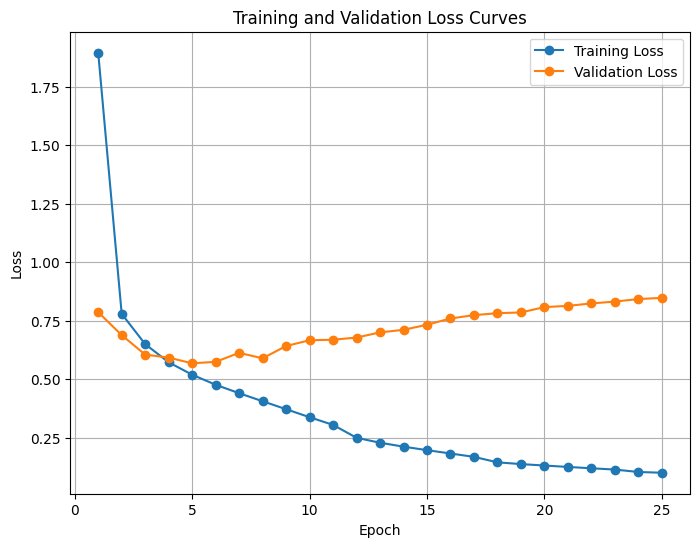

In [206]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o', label="Training Loss")
plt.plot(range(1, len(val_losses) + 1), val_losses, marker='o', label="Validation Loss") 
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Curves")
plt.legend()
plt.grid(True)
plt.show()



In [207]:
def generate_predictions(model, val_loader):
    model.eval()
    predictions = []
    with torch.no_grad():
        for users, items, ratings in val_loader:
            user, item = users.to(device), items.to(device)
            prediction = model(user, item)
            predictions.extend(prediction.cpu().numpy())
    return predictions

predictions = generate_predictions(model, val_loader)
prediction_df = pd.DataFrame({
    'ReviewerID': validation_data['ReviewerID'].values,
    'ProductID': validation_data['ProductID'].values,
    'Star': predictions
})

prediction_df.to_csv('predictions_nncf_2.csv', index=False)


In [199]:
df_val['ReviewerID']


0       1876
1       2360
2        283
3       1920
4       2289
        ... 
6591     208
6592    1012
6593     665
6594    2124
6595    1827
Name: ReviewerID, Length: 6596, dtype: int32

In [201]:
validation_data['ReviewerID']


0       A25X28UZCW2J6G
1       A1FUH1O6FCTUYG
2        AAUVEEG5YLZAX
3       A3VQLGTYTL5196
4       A10JAUCIGVRW9F
             ...      
6591    A3TC60MGLW1I76
6592     AGE0YGLF7L2ZL
6593     AT2ZB20OCU7X2
6594    A1ACUN6A2LYVMW
6595    A1BOK1EC36Q0WV
Name: ReviewerID, Length: 6596, dtype: object

In [44]:
def compute_rmse(model, loader):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for brand, wide, ratings in loader:
            outputs = model(
                brand.to(device),
                wide.to(device)
            )
            total_loss += nn.MSELoss(reduction='sum')(outputs, ratings.to(device)).item()
    mse = total_loss / len(loader.dataset)
    return torch.sqrt(torch.tensor(mse)).item()

train_rmse = compute_rmse(model, train_loader)
val_rmse = compute_rmse(model, val_loader)

print(f"Train RMSE: {train_rmse:.4f}")
print(f"Validation RMSE: {val_rmse:.4f}")

Train RMSE: 0.4127
Validation RMSE: 1.2996


In [46]:
train_rmse = compute_rmse(model, train_loader)
val_rmse = compute_rmse(model, val_loader)

print(f"Train RMSE: {train_rmse:.4f}")
print(f"Validation RMSE: {val_rmse:.4f}")

Train RMSE: 0.2439
Validation RMSE: 1.5640


In [47]:
test_loader = DataLoader(RatingDataset(df_test), batch_size=64, shuffle=False, pin_memory=True)
test_rmse = compute_rmse(model, test_loader)
print(f"Test RMSE: {test_rmse:.4f}")

Test RMSE: 4.0297


## TODO: Hyper param tuning

In [ ]:
from ray import tune
from ray.tune.search import BayesOptSearch
from ray.tune import CLIReporter
from ray.tune import Checkpoint

import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = NeuralCF(num_users=len(user_map), num_items=len(item_map)).to(device)
model.to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(42)

num_epochs = 50

train_dataset = RatingDataset(df_train)
val_dataset = RatingDataset(df_val)

# train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,
#                           pin_memory=True)

val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False,
                        pin_memory=True)

early_stopping = EarlyStopping(patience=10, min_delta=0.01)

lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer,
                                                     mode='min', patience=5, factor=0.5)

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for users, items, ratings in train_loader:
        user, item, rating = users.to(device), items.to(device), ratings.to(device)
        optimizer.zero_grad()
        pred = model(user, item)
        loss = criterion(pred, rating)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(train_loader))
    print(f"Epoch {epoch+1} train loss: {train_losses[-1]:.4f}")

    avg_train_loss = sum(train_losses) / len(train_losses)
    print(f"Average train loss: {avg_train_loss:.4f}")

    model.eval()
    val_epoch_loss = 0
    with torch.no_grad():
        for users, items, ratings in dev_loader:
            user, item, rating = users.to(device), items.to(device), ratings.to(device)
            pred = model(user, item)
            loss = criterion(pred, rating)
            val_epoch_loss += loss.item()
    avg_val_loss = val_epoch_loss / len(dev_loader)
    val_losses.append(avg_val_loss)
    print(f"Average validation loss: {avg_val_loss:.4f}")

    if early_stopping(avg_val_loss):
        print("Early stopping triggered")
        break

    lr_scheduler.step(avg_val_loss)

